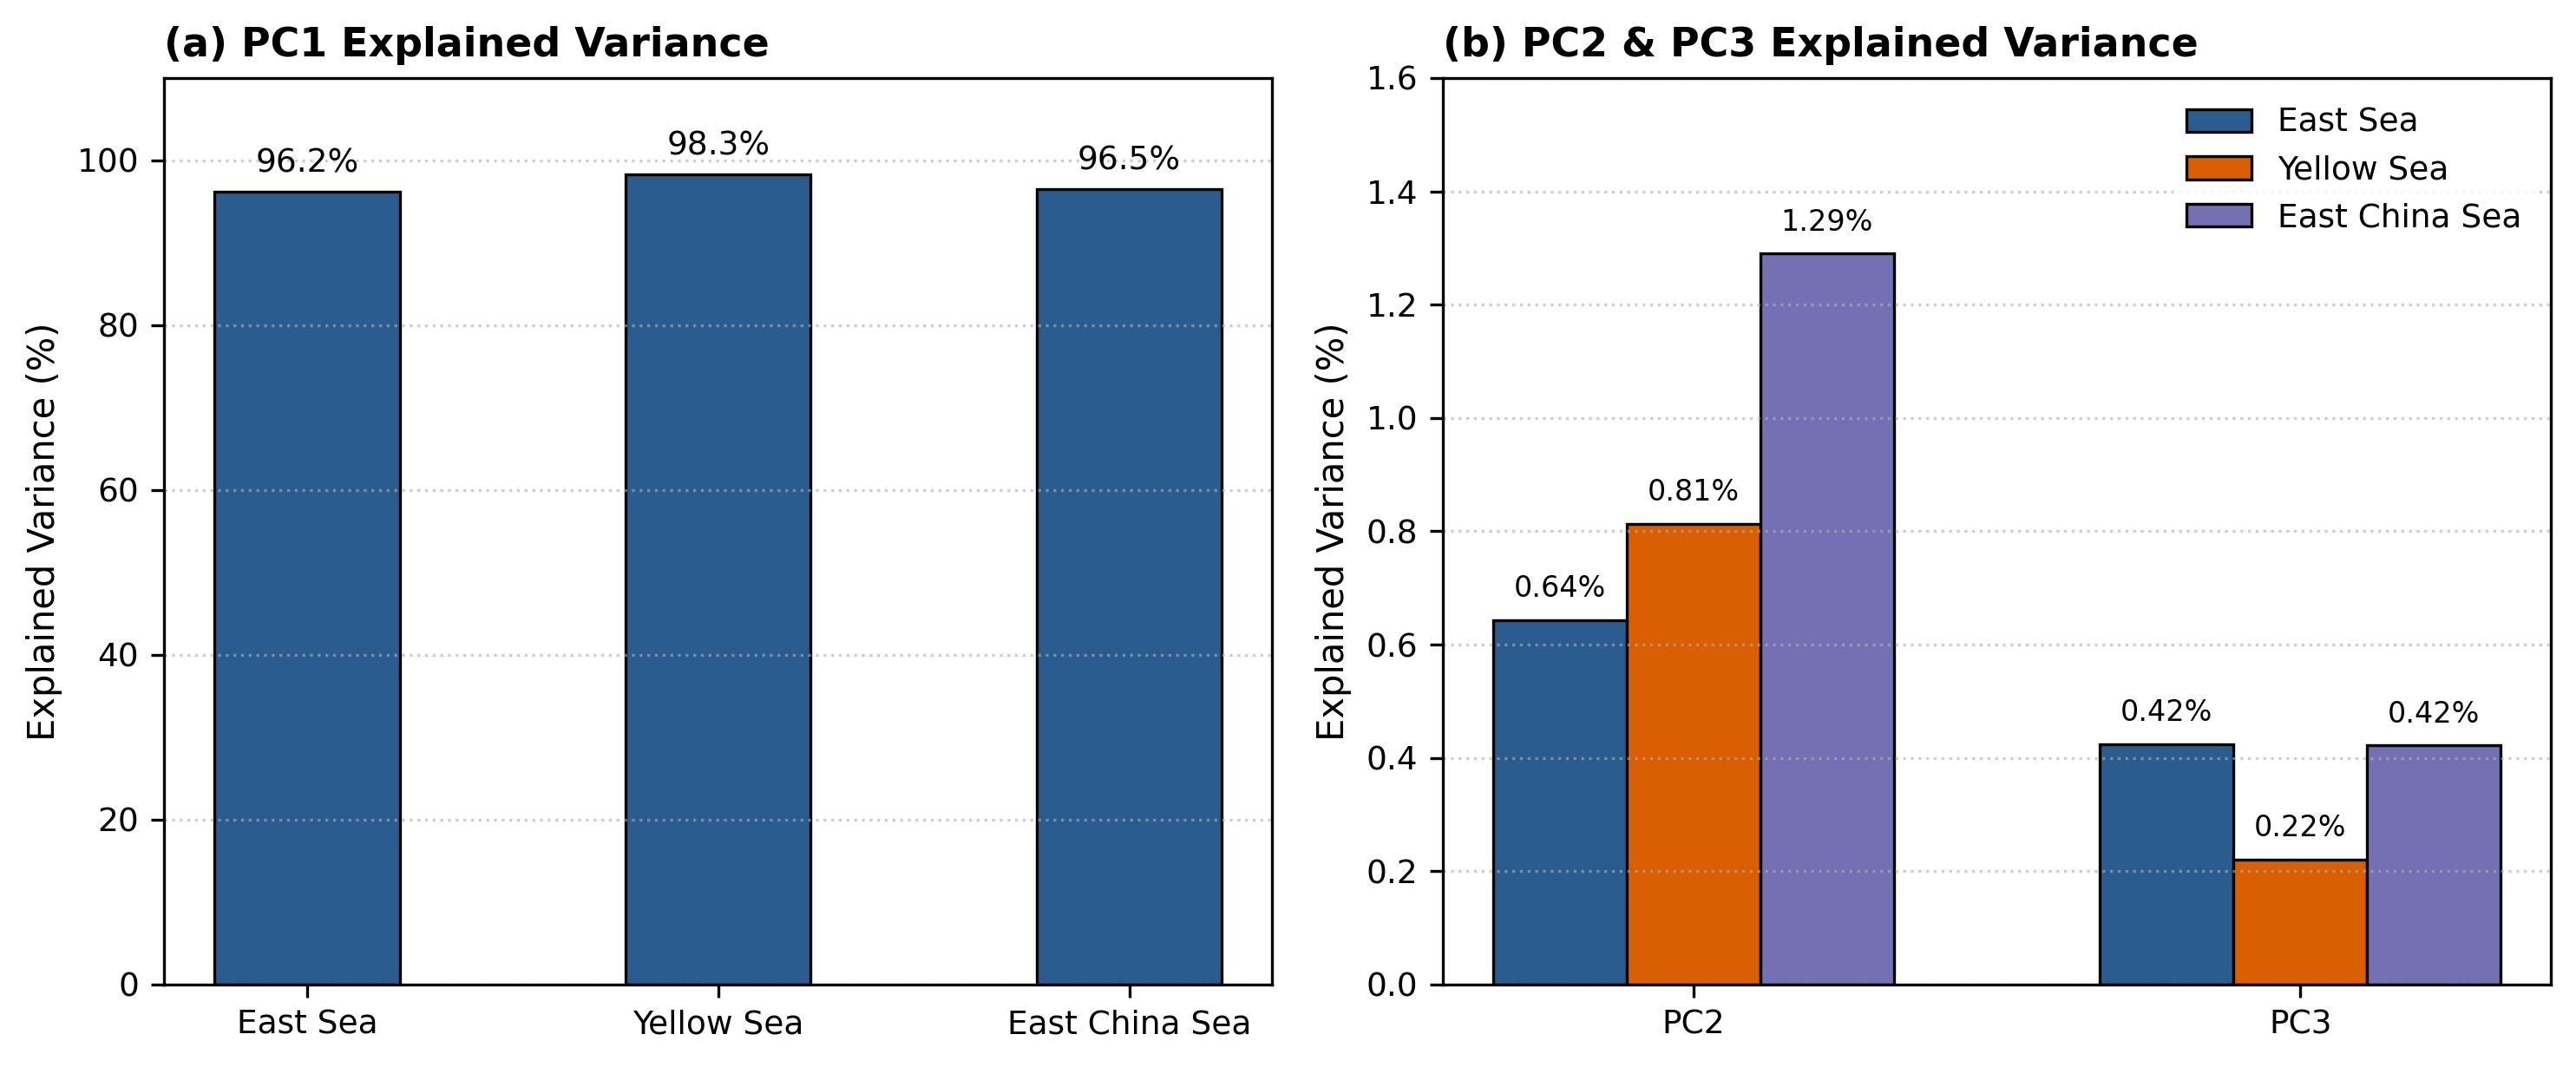

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Set publication-quality typography defaults
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['mathtext.fontset'] = 'dejavusans'

# ============================================================
# PCA Explained Variance Ratios (Converted to Percentages)
# ============================================================

regions = ["East Sea", "Yellow Sea", "East China Sea"]

# Convert ratios to percentages (%) for better readability
pc1 = np.array([0.961915, 0.982932, 0.965095]) * 100
pc2 = np.array([0.006428, 0.008131, 0.012904]) * 100
pc3 = np.array([0.004244, 0.002208, 0.004220]) * 100

# Colorblind-friendly palette (Muted professional blues/teals)
colors = ["#2b5c8f", "#d95f02", "#7570b3"]

# ============================================================
# Figure Setup
# ============================================================

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(10, 4.2),
    dpi=300
)

width = 0.22
x = np.arange(len(regions))

# ============================================================
# Panel (a): PC1
# ============================================================

bars1 = ax1.bar(
    x,
    pc1,
    width=0.45,
    color="#2b5c8f",
    edgecolor="black",
    linewidth=0.8
)

ax1.set_title("(a) PC1 Explained Variance", fontsize=11, fontweight='bold', loc='left')
ax1.set_ylabel("Explained Variance (%)", fontsize=10)
ax1.set_xticks(x)
ax1.set_xticklabels(regions, rotation=0, fontsize=9.5)
ax1.set_ylim(0, 110)  # Honest baseline starting at 0%

ax1.grid(axis='y', linestyle=':', alpha=0.6)

for bar in bars1:
    h = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        h + 1.5,
        f"{h:.1f}%",
        ha='center',
        va='bottom',
        fontsize=9
    )

# ============================================================
# Panel (b): PC2 & PC3
# ============================================================

x2 = np.arange(2)

ax2.bar(x2 - width, [pc2[0], pc3[0]], width, label="East Sea", color=colors[0], edgecolor="black", linewidth=0.8)
ax2.bar(x2, [pc2[1], pc3[1]], width, label="Yellow Sea", color=colors[1], edgecolor="black", linewidth=0.8)
ax2.bar(x2 + width, [pc2[2], pc3[2]], width, label="East China Sea", color=colors[2], edgecolor="black", linewidth=0.8)

ax2.set_title("(b) PC2 & PC3 Explained Variance", fontsize=11, fontweight='bold', loc='left')
ax2.set_ylabel("Explained Variance (%)", fontsize=10)
ax2.set_xticks(x2)
ax2.set_xticklabels(["PC2", "PC3"], fontsize=9.5)
ax2.set_ylim(0, 1.6)  # Fits the percentages comfortably

ax2.grid(axis='y', linestyle=':', alpha=0.6)

ax2.legend(
    frameon=True,
    facecolor='white',
    edgecolor='none',
    fontsize=9
)

# Precise percentage formatting for small components
for container in ax2.containers:
    for bar in container:
        h = bar.get_height()
        if h > 0:
            ax2.text(
                bar.get_x() + bar.get_width() / 2,
                h + 0.03,
                f"{h:.2f}%",  # 2 decimal places preserves necessary precision
                ha='center',
                va='bottom',
                fontsize=8
            )

# ============================================================
# Global Publication Polish
# ============================================================

for ax in [ax1, ax2]:
    ax.tick_params(axis='both', which='major', labelsize=9)
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

plt.tight_layout()

# Save as PDF or EPS for vector-graphics compliance in major journals
plt.savefig("PCA_Explained_Variance.pdf", format="pdf", bbox_inches="tight")
plt.savefig("PCA_Explained_Variance.png", dpi=600, bbox_inches="tight")

plt.show()